# Appendix 3. The preprocessing, on one spectrum

One raw spectrum next to its preprocessed form, to show what notebook 1 does to
the data.  The spectrum is picked by its `filename_csv` and its column in
`F30_norm.csv` is found from the `<SN name>%%%<SN type>$$$<phase>` label, so
nothing here depends on a row or column number.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0 |
| `spectrum/<filename_csv>` | the raw spectrum drawn here |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |

| output | what it shows |
| --- | --- |
| `figure/comp_spec.pdf` / `.png` | the median-normalized raw spectrum and the preprocessed one, over the same rest-frame range |


## Imports


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import astropy.units as u

import warnings
from astropy.utils.exceptions import AstropyDeprecationWarning

warnings.filterwarnings("ignore", category=AstropyDeprecationWarning)

## Configuration


In [3]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_DIR = './spectrum'

SPECTRUM_TABLE_DIR = './data'
NORMALIZED_TABLE_NAME = 'F30_norm.csv'
NORMALIZED_TABLE_PATH = f'{SPECTRUM_TABLE_DIR}/{NORMALIZED_TABLE_NAME}'

FIGURE_DIR = './figure'
OUTPUT_NAME = 'comp_spec'

# The spectrum drawn here, named as `params.csv` names it
TARGET_FILENAME_CSV = '2008Q_2008-02-09_02-09-36_FLWO-1.5m_FAST_CfA-Ia.csv'

# Rest-frame range of the figure [Angstrom]; the grid of notebook 1
PLOT_MIN_AA = 5000
PLOT_MAX_AA = 7000

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'
TYPE_PHASE_SEPARATOR = '$$$'


In [4]:
def make_column_label(sn_name, sn_type, phase):
    """Encode the identity of a supernova into a single column label."""
    return f'{sn_name}{NAME_TYPE_SEPARATOR}{sn_type}{TYPE_PHASE_SEPARATOR}{phase}'

def load_rest_frame_arrays(spectrum_path, redshift):
    """Replicate the input/rest-frame part of legacy `read_spec()`."""
    # Legacy code reads the full CSV, then uses columns 0 and 1.
    data = pd.read_csv(spectrum_path, header=None)
    data.drop_duplicates(subset=0, inplace=True)

    AA = data[0] / (1.0 + redshift)
    flux = data[1] * (1.0 + redshift)

    return AA, flux


In [5]:
metadata = pd.read_csv(PARAMS_PATH)

target = metadata[metadata['filename_csv'] == TARGET_FILENAME_CSV].iloc[0]
raw_path = os.path.join(SPECTRUM_DIR, target['filename_csv'])
redshift = target['redshift']
column_label = make_column_label(target['SN_name'], target['SN_type'], target['phase'])

print(f'{target["SN_name"]}  z={redshift:.5f}')
print(f'raw      : {raw_path}')
print(f'processed: {NORMALIZED_TABLE_PATH}  column {column_label!r}')


SN2008Q  z=0.00810
raw      : ./spectrum/2008Q_2008-02-09_02-09-36_FLWO-1.5m_FAST_CfA-Ia.csv
processed: ./data/F30_norm.csv  column 'SN2008Q%%%NV$$$-0.31'


In [6]:
AA_raw, flux_raw = load_rest_frame_arrays(raw_path, redshift)
mask_raw = (AA_raw > PLOT_MIN_AA) & (AA_raw < PLOT_MAX_AA)


In [7]:
normalized = pd.read_csv(NORMALIZED_TABLE_PATH)

mask_normalized = (normalized['AA'] > PLOT_MIN_AA) & (normalized['AA'] < PLOT_MAX_AA)
normalized_AA = normalized['AA'][mask_normalized]
normalized_flux = normalized[column_label][mask_normalized]


In [8]:
plt.rcParams['figure.figsize'] = (10.0, 4.5)
plt.rcParams['figure.dpi'] = 300

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams["xtick.minor.visible"] = 'True'
plt.rcParams["ytick.minor.visible"] = 'True'

plt.rcParams["xtick.major.width"] = 1
plt.rcParams["ytick.major.width"] = 1
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 7
plt.rcParams["ytick.major.size"] = 7
plt.rcParams["xtick.minor.size"] = 4
plt.rcParams["ytick.minor.size"] = 4

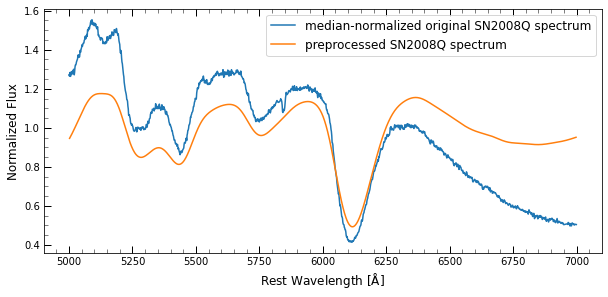

In [11]:
os.makedirs(FIGURE_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(10,4.5))
median_flux = flux_raw / np.median(flux_raw[mask_raw])

ax.plot(AA_raw[mask_raw], median_flux[mask_raw],
        label=f'median-normalized original {target["SN_name"]} spectrum')
ax.plot(normalized_AA, normalized_flux,
        label=f'preprocessed {target["SN_name"]} spectrum')

ax.set_xlabel(r'Rest Wavelength [${\rm \AA}$]', fontsize=12)
ax.set_ylabel(r'Normalized Flux', fontsize=12)
ax.legend(fontsize=12)

fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.png', bbox_inches='tight', pad_inches=0.05)
plt.show()
